In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set thesis-quality plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 6)

# Load the final merged validation dataframe
# This contains 'photovoltaik', 'windkraft', and all model predictions
df = pd.read_parquet('../results/kwusterhausen/kw_multi_model_validation.parquet')

# Slice to the most recent 7 days for the time-series plots. The validator's
# rolling window keeps growing, and BiLSTM/TFT predictions only start partway
# into the history, so a hardcoded date range goes stale (or ends up mostly
# NaN for the sequence models) as soon as the underlying parquet is refreshed.
df_week = df.tail(24 * 7)

print(f"Loaded {len(df)} validation hours.")
df.head()

Loaded 755 validation hours.


,photovoltaik,windkraft,pred_lightgbm_wind,pred_xgboost_wind,pred_ebm_wind,pred_bilstm_wind,pred_lightgbm_solar,pred_xgboost_solar,pred_ebm_solar,pred_bilstm_solar,pred_tft_wind,pred_tft_solar
2026-05-28 13:00:00+00:00,2310.840468,238.119917,579.050284,580.039612,699.431826,NaN,2681.093695,2732.436523,2638.627379,NaN,NaN,NaN
2026-05-28 14:00:00+00:00,2132.708920,447.309750,600.755802,575.120850,769.872278,NaN,2355.121973,2393.712891,2318.482766,NaN,NaN,NaN
2026-05-28 15:00:00+00:00,1720.170671,392.132958,633.886100,594.844177,803.936531,NaN,1842.883222,1841.547607,1751.507876,NaN,NaN,NaN
2026-05-28 16:00:00+00:00,1205.762887,184.819250,611.329037,538.315552,567.517318,NaN,1188.126157,1107.206421,1126.840329,NaN,NaN,NaN
2026-05-28 17:00:00+00:00,684.364520,668.303917,453.443752,430.515991,421.061911,NaN,521.141626,464.465210,491.260240,NaN,NaN,NaN


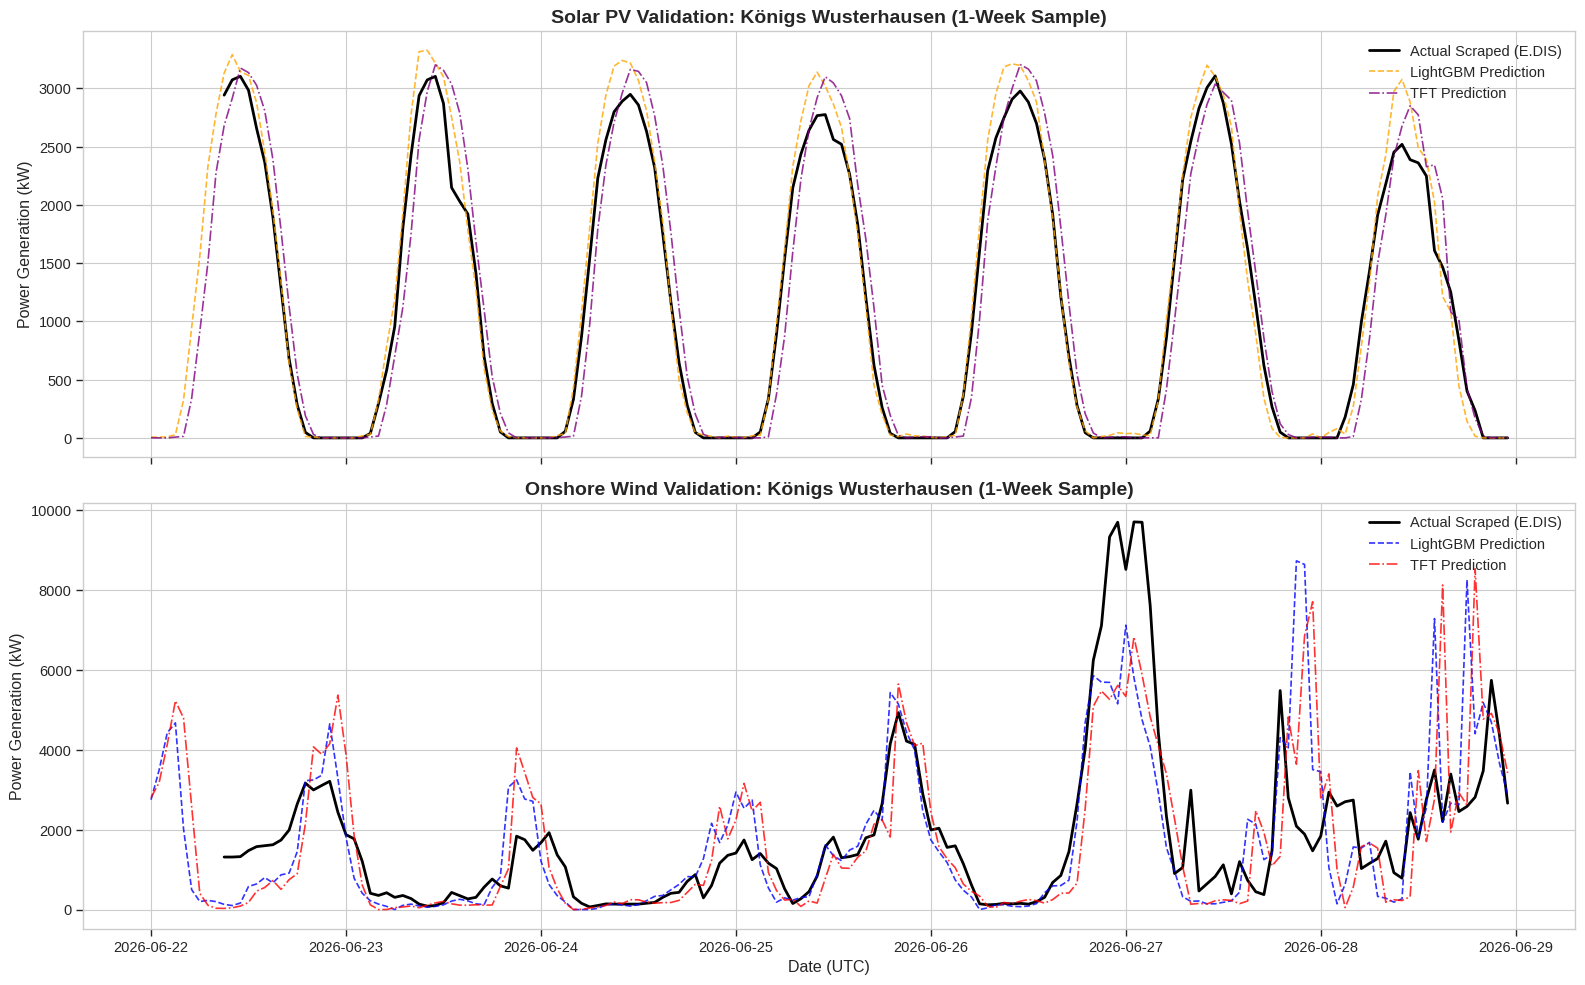

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Top Panel: Solar Validation ---
axes[0].plot(df_week.index, df_week['photovoltaik'], label='Actual Scraped (E.DIS)', color='black', linewidth=2)
axes[0].plot(df_week.index, df_week['pred_lightgbm_solar'], label='LightGBM Prediction', color='orange', linestyle='--', alpha=0.8)
axes[0].plot(df_week.index, df_week['pred_tft_solar'], label='TFT Prediction', color='purple', linestyle='-.', alpha=0.8)

axes[0].set_title('Solar PV Validation: Königs Wusterhausen (1-Week Sample)', fontsize=14, weight='bold')
axes[0].set_ylabel('Power Generation (kW)')
axes[0].legend(loc='upper right')

# --- Bottom Panel: Wind Validation ---
axes[1].plot(df_week.index, df_week['windkraft'], label='Actual Scraped (E.DIS)', color='black', linewidth=2)
axes[1].plot(df_week.index, df_week['pred_lightgbm_wind'], label='LightGBM Prediction', color='blue', linestyle='--', alpha=0.8)
axes[1].plot(df_week.index, df_week['pred_tft_wind'], label='TFT Prediction', color='red', linestyle='-.', alpha=0.8)

axes[1].set_title('Onshore Wind Validation: Königs Wusterhausen (1-Week Sample)', fontsize=14, weight='bold')
axes[1].set_ylabel('Power Generation (kW)')
axes[1].set_xlabel('Date (UTC)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../documentation/kw_timeseries_validation.png', dpi=300)
plt.show()

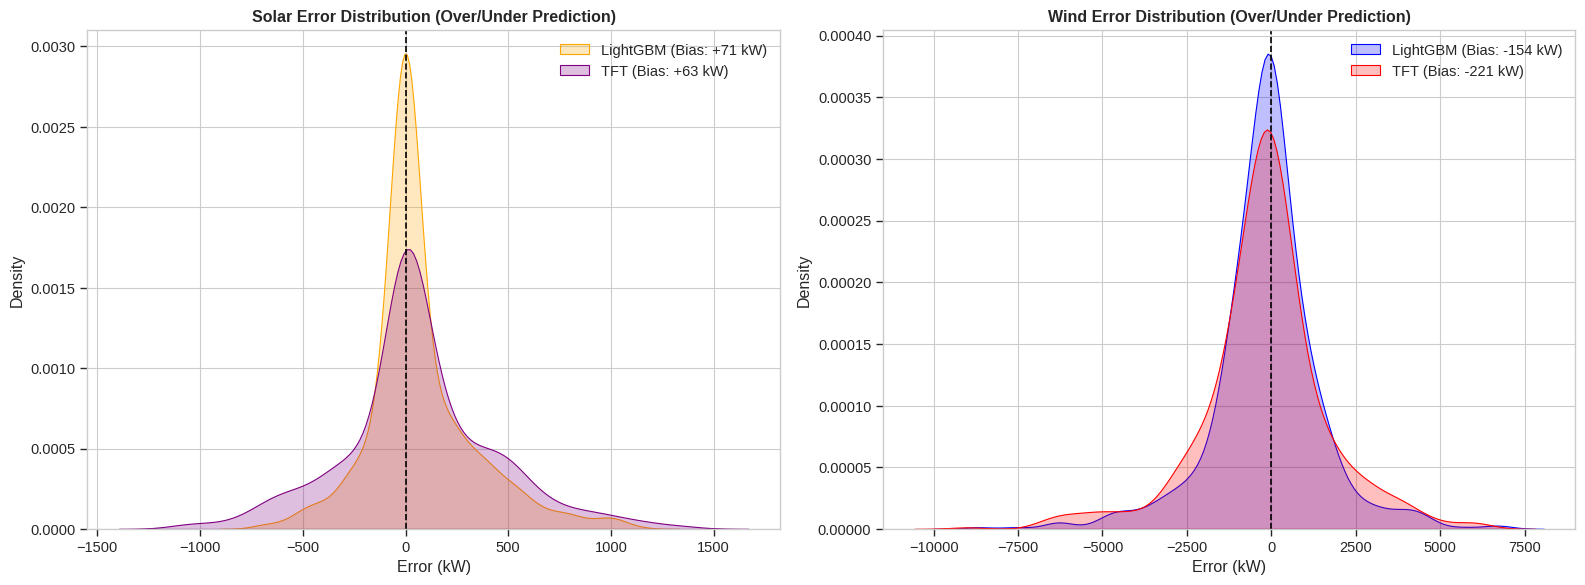

In [3]:
# Calculate residuals (Prediction - Actual)
# Positive means the model over-predicted, Negative means under-predicted
res_lgb_solar = df['pred_lightgbm_solar'] - df['photovoltaik']
res_tft_solar = df['pred_tft_solar'] - df['photovoltaik']

res_lgb_wind = df['pred_lightgbm_wind'] - df['windkraft']
res_tft_wind = df['pred_tft_wind'] - df['windkraft']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Solar Error Distribution
sns.kdeplot(res_lgb_solar, ax=axes[0], fill=True, label=f'LightGBM (Bias: {res_lgb_solar.mean():+.0f} kW)', color='orange')
sns.kdeplot(res_tft_solar, ax=axes[0], fill=True, label=f'TFT (Bias: {res_tft_solar.mean():+.0f} kW)', color='purple')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Solar Error Distribution (Over/Under Prediction)', weight='bold')
axes[0].set_xlabel('Error (kW)')
axes[0].legend()

# Wind Error Distribution
sns.kdeplot(res_lgb_wind, ax=axes[1], fill=True, label=f'LightGBM (Bias: {res_lgb_wind.mean():+.0f} kW)', color='blue')
sns.kdeplot(res_tft_wind, ax=axes[1], fill=True, label=f'TFT (Bias: {res_tft_wind.mean():+.0f} kW)', color='red')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Wind Error Distribution (Over/Under Prediction)', weight='bold')
axes[1].set_xlabel('Error (kW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../documentation/kw_bias_distribution.png', dpi=300)
plt.show()

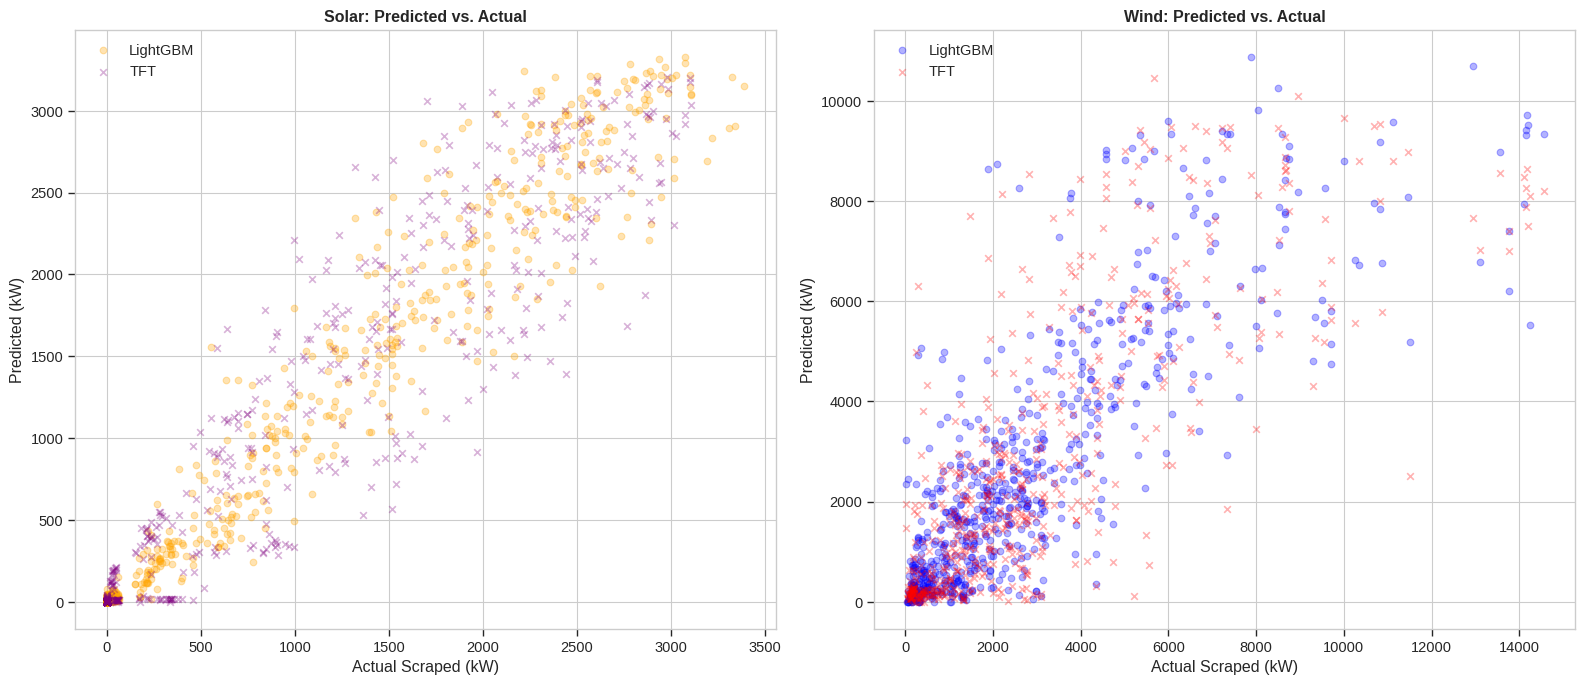

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Solar Scatter
axes[0].scatter(df['photovoltaik'], df['pred_lightgbm_solar'], alpha=0.3, color='orange', label='LightGBM')
axes[0].scatter(df['photovoltaik'], df['pred_tft_solar'], alpha=0.3, color='purple', marker='x', label='TFT')
# Perfect prediction line
max_solar = max(df['photovoltaik'].max(), df['pred_tft_solar'].max())
#axes[0].plot([0, max_solar], [0, max_solar], 'k--', label='Perfect 1:1')
axes[0].set_title('Solar: Predicted vs. Actual', weight='bold')
axes[0].set_xlabel('Actual Scraped (kW)')
axes[0].set_ylabel('Predicted (kW)')
axes[0].legend()

# Wind Scatter
axes[1].scatter(df['windkraft'], df['pred_lightgbm_wind'], alpha=0.3, color='blue', label='LightGBM')
axes[1].scatter(df['windkraft'], df['pred_tft_wind'], alpha=0.3, color='red', marker='x', label='TFT')
max_wind = max(df['windkraft'].max(), df['pred_lightgbm_wind'].max())
#axes[1].plot([0, max_wind], [0, max_wind], 'k--', label='Perfect 1:1')
axes[1].set_title('Wind: Predicted vs. Actual', weight='bold')
axes[1].set_xlabel('Actual Scraped (kW)')
axes[1].set_ylabel('Predicted (kW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../documentation/kw_scatter_validation.png', dpi=300)
plt.show()